In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv(r"D:\Projects\dataest-project\Coffeesales.csv")

In [5]:
df.head(5)

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3263 entries, 0 to 3262
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3263 non-null   str    
 1   datetime     3263 non-null   str    
 2   cash_type    3263 non-null   str    
 3   card         3174 non-null   str    
 4   money        3263 non-null   float64
 5   coffee_name  3263 non-null   str    
dtypes: float64(1), str(5)
memory usage: 153.1 KB


In [7]:
df['date']= pd.to_datetime(df['date'])

In [8]:
df['time']=pd.to_datetime(df['datetime']).dt.strftime("%H:%M:%S")
df.drop('datetime', axis=1, inplace=True) # Removing the old column
df.drop_duplicates(inplace=True)

In [9]:
df.head(5)

,date,cash_type,card,money,coffee_name,time
0,2024-03-01,card,ANON-0000-0000-0001,38.7,Latte,10:15:50
1,2024-03-01,card,ANON-0000-0000-0002,38.7,Hot Chocolate,12:19:22
2,2024-03-01,card,ANON-0000-0000-0002,38.7,Hot Chocolate,12:20:18
3,2024-03-01,card,ANON-0000-0000-0003,28.9,Americano,13:46:33
4,2024-03-01,card,ANON-0000-0000-0004,38.7,Latte,13:48:14


In [10]:
# Total Revenue and average spending per transaction
print("The Total Revenue: {:.1f}".format(df['money'].sum()))
print('The Average Spending: {:.1f}'.format(df['money'].mean()))

The Total Revenue: 103759.1
The Average Spending: 31.8


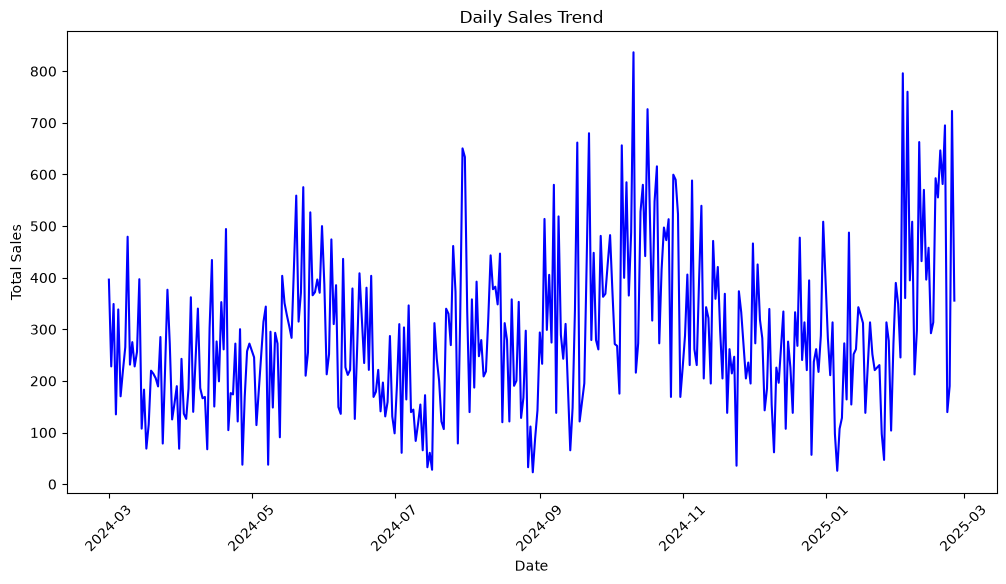

In [11]:
daily_sales= df.groupby ('date')['money'].sum()
plt.figure(figsize=(12,6))
plt.plot(daily_sales.index, daily_sales.values, color='b')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.title('Daily Sales Trend')
plt.xticks(rotation=45)
plt.show()

In [12]:
# Best-selling product analysis
df['coffee_name'].value_counts()

coffee_name
Americano with Milk    764
Latte                  714
Americano              459
Cappuccino             452
Cortado                289
Hot Chocolate          256
Cocoa                  207
Espresso               122
Name: count, dtype: int64

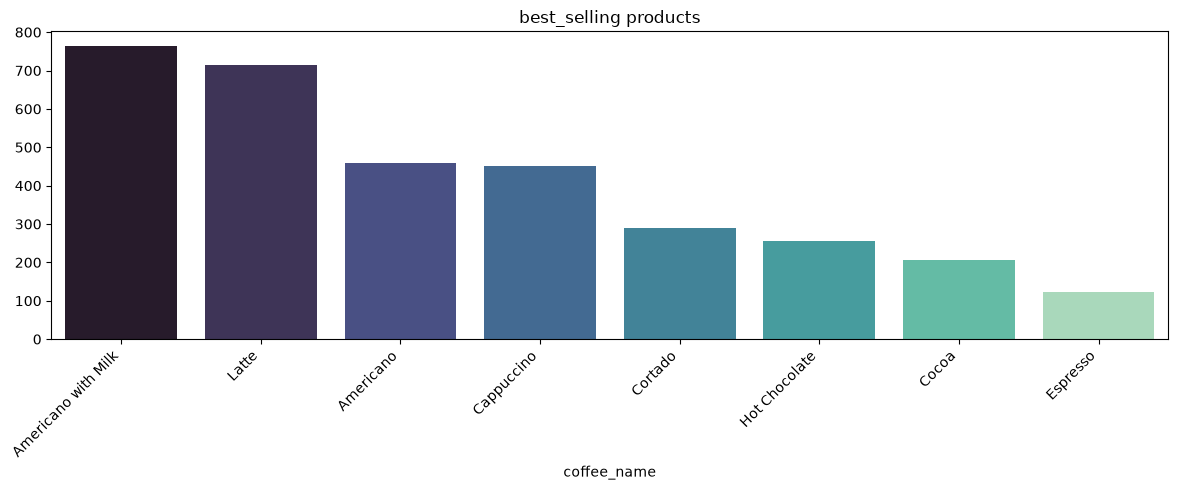

In [13]:
# Best Selling Coffee Chart
plt.figure(figsize=(12,5))
sns.barplot(x=df['coffee_name'].value_counts().index, y=df['coffee_name'].value_counts().values, palette='mako',  hue=df['coffee_name'].value_counts().index,)
plt.title("best_selling products")
plt.xlabel('coffee_name')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [14]:
# Total revenue for each type of coffee
df.groupby('coffee_name')['money'].sum().sort_values(ascending=False)

coffee_name
Latte                  25434.62
Americano with Milk    23417.52
Cappuccino             16281.90
Americano              11973.02
Hot Chocolate           9242.70
Cortado                 7456.98
Cocoa                   7390.80
Espresso                2561.56
Name: money, dtype: float64

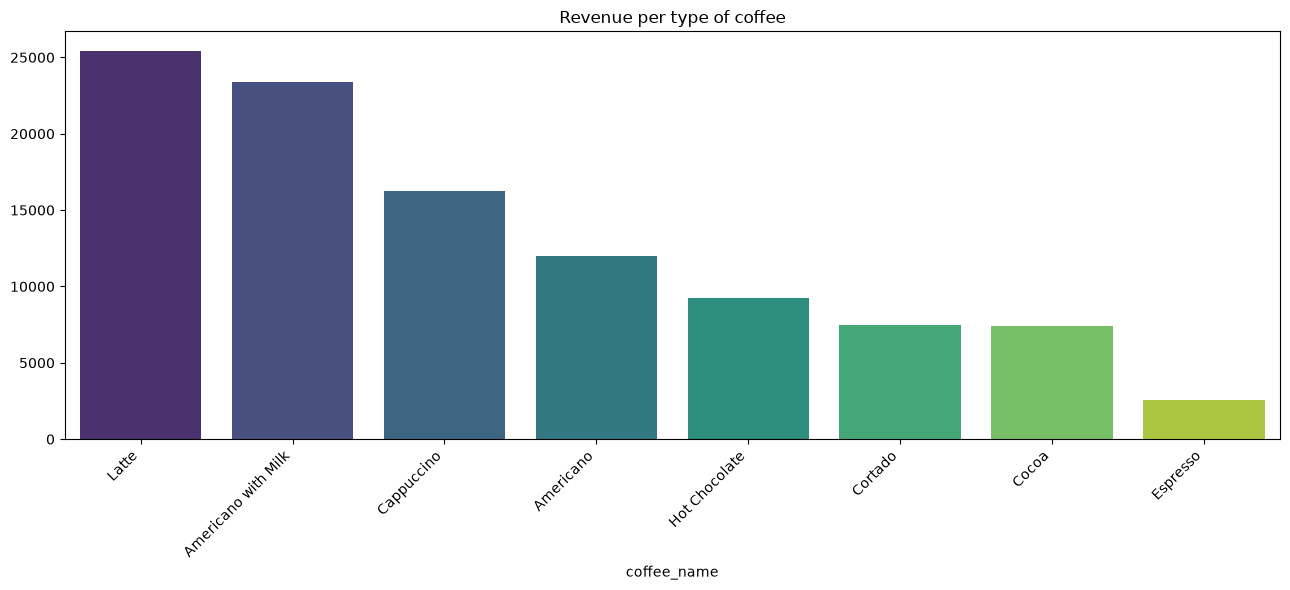

In [15]:
# Revenue chart for each type of coffee.
coffee_revenue= df.groupby('coffee_name')['money'].sum().sort_values(ascending=False)
plt.figure(figsize=(13,6))
sns.barplot(x=coffee_revenue.index, y=coffee_revenue.values, palette='viridis', hue=coffee_revenue.index)
plt.title("Revenue per type of coffee")
plt.xlabel('coffee_name')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [16]:
# Payment methods distribution account
df['cash_type'].value_counts()

cash_type
card    3174
cash      89
Name: count, dtype: int64

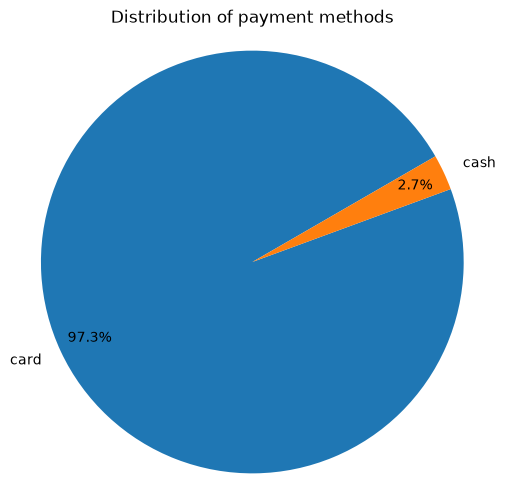

In [17]:
# pie chart of payment methods
plt.figure(figsize=(6,6))
plt.pie(df['cash_type'].value_counts(), labels=df['cash_type'].value_counts().index, autopct='%1.1f%%', startangle=30, pctdistance=0.85)
plt.axis('equal')
plt.title('Distribution of payment methods')
plt.show()

In [18]:
# Take the top 10 customers by number of purchases
df['card'].value_counts().head(10)

card
ANON-0000-0000-0012    129
ANON-0000-0000-0141    108
ANON-0000-0000-0276     69
ANON-0000-0000-0009     67
ANON-0000-0000-0040     50
ANON-0000-0000-0507     50
ANON-0000-0000-0097     47
ANON-0000-0000-1163     46
ANON-0000-0000-0003     31
ANON-0000-0000-0570     30
Name: count, dtype: int64

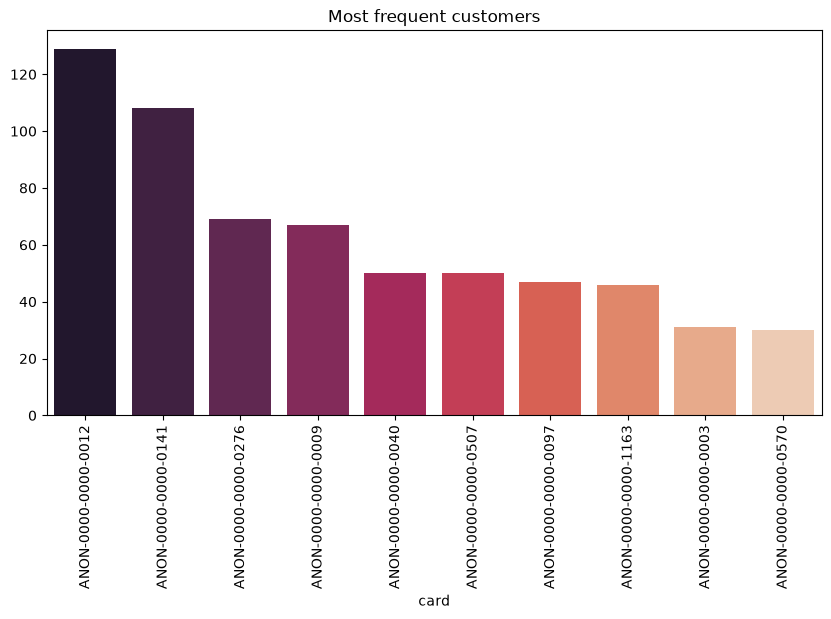

In [19]:
# Chart of repeat customers
top_customers= df['card'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_customers.index, y=top_customers.values, palette='rocket', hue=top_customers.index)
plt.xticks(rotation=90)
plt.title('Most frequent customers')
plt.show()

In [20]:
# Extract hours from `datetime`

df['hour']= pd.to_datetime(df['time'], format='%H:%M:%S').dt.hour
# the number of sales per hour
df.groupby('hour').size()

hour
6       2
7      78
8     212
9     214
10    313
11    263
12    231
13    209
14    201
15    202
16    241
17    209
18    189
19    224
20    165
21    194
22    116
dtype: int64

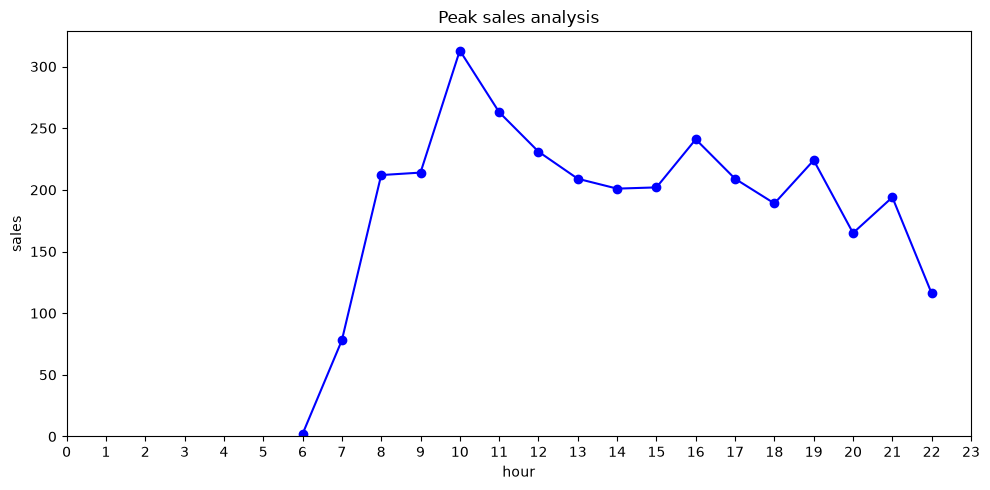

In [21]:
# Peak time chart
plt.figure(figsize=(10,5))
df.groupby('hour').size().plot(marker='o',  color='b')
plt.ylabel('sales')
plt.title('Peak sales analysis')
plt.xticks(range(0,24))
plt.ylim(bottom=0)
plt.tight_layout()


In [22]:
hourly_sales= (
    df.groupby('hour')['money'].agg(
        revenue='sum',
        transaction='count',
        average_order_value='mean'
    )
).reset_index()
peak_hour= hourly_sales.loc[
    hourly_sales['revenue'].idxmax()
]
print('Peak Hour:' , peak_hour['hour'])
print('Revenue:' , peak_hour['revenue'])
print('Transaction:' , peak_hour['transaction'])

Peak Hour: 10.0
Revenue: 9868.86
Transaction: 313.0


In [23]:
# Extract days from `date`
df['weekday']=df['date'].dt.day_name()
# Total sales for each day of the week
df.groupby('weekday')['money'].sum()


weekday
Friday       14856.94
Monday       16232.18
Saturday     14117.12
Sunday       13062.06
Thursday     14533.22
Tuesday      17193.32
Wednesday    13764.26
Name: money, dtype: float64

In [24]:
# Arrange the days correctly
sales_weekday= df.groupby('weekday')['money'].sum()
days_order= ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sales_weekday=sales_weekday.reindex(days_order)
sales_weekday

weekday
Monday       16232.18
Tuesday      17193.32
Wednesday    13764.26
Thursday     14533.22
Friday       14856.94
Saturday     14117.12
Sunday       13062.06
Name: money, dtype: float64

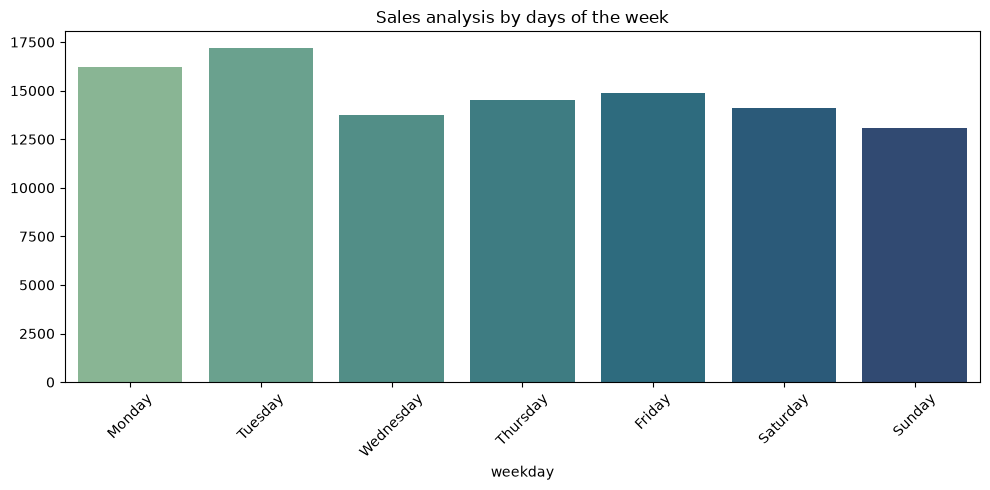

In [25]:
# Sales chart by days of the week
plt.figure(figsize=(10,5))
sns.barplot(x=sales_weekday.index, y=sales_weekday.values, palette="crest", hue=sales_weekday.index)
plt.title("Sales analysis by days of the week")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

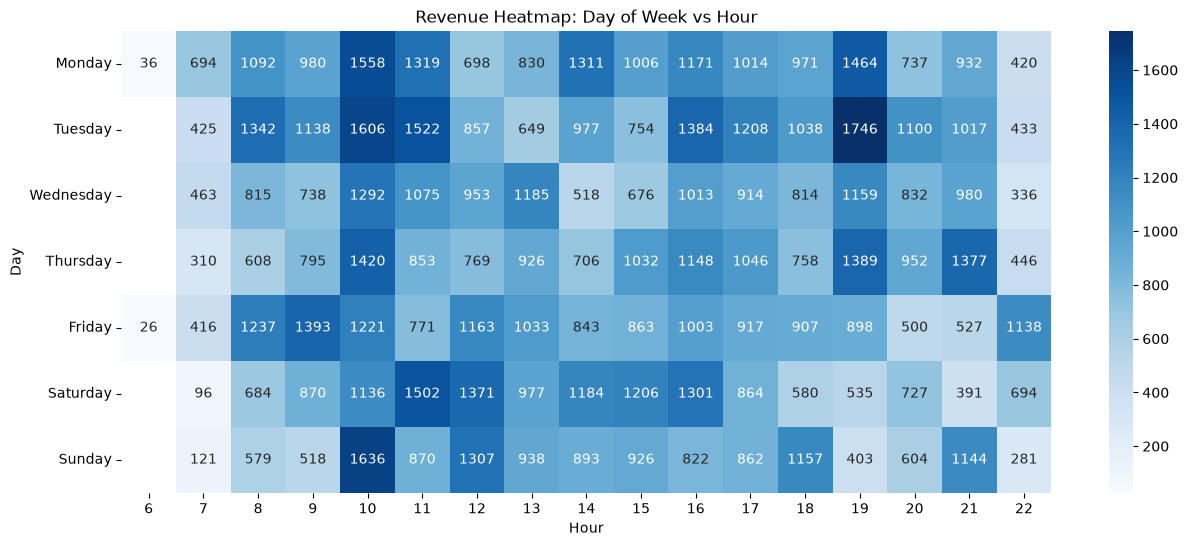

In [26]:
heatmap_data= pd.pivot_table(
    df, 
    values='money',
    index='weekday',
    columns='hour',
    aggfunc='sum'
)
heatmap_data = heatmap_data.reindex(days_order)


plt.figure(figsize=(15,6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0f',
    cmap='Blues'
)

plt.title("Revenue Heatmap: Day of Week vs Hour")
plt.xlabel('Hour')
plt.ylabel('Day');

In [27]:
#export months from 'data'
df['month']= df['date'].dt.month

#monthly sales

df.groupby('month')['money'].sum()

month
1      6398.86
2     11529.44
3      7050.20
4      6720.56
5      9063.42
6      7758.76
7      6915.94
8      7613.84
9      9988.64
10    13891.16
11     8590.54
12     8237.74
Name: money, dtype: float64

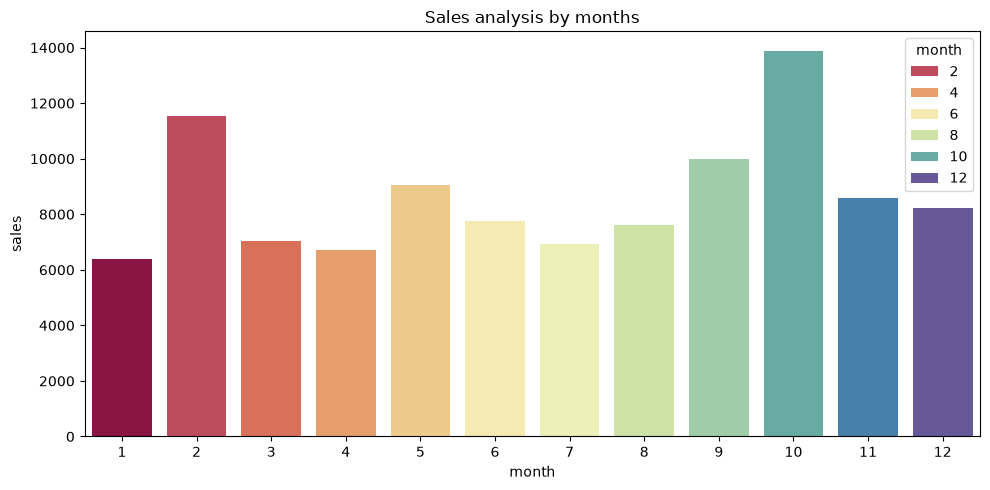

In [28]:
# sales_monthly chart 
plt.figure(figsize=(10,5))
sales_monthly=df.groupby('month')['money'].sum()
sns.barplot(x=sales_monthly.index, y=sales_monthly.values, hue=sales_monthly.index, palette='Spectral')
plt.ylabel('sales')
plt.title('Sales analysis by months')
plt.tight_layout()


In [29]:
# month over month growth
sales_monthly = df.groupby('month', as_index=False)['money'].sum()
sales_monthly['MOM_Growth']= (
    sales_monthly['money'].pct_change()*100
)
sales_monthly

,month,money,MOM_Growth
0,1,6398.86,NaN
1,2,11529.44,80.179594
2,3,7050.20,-38.850456
3,4,6720.56,-4.675612
4,5,9063.42,34.861083
5,6,7758.76,-14.394787
6,7,6915.94,-10.862818
7,8,7613.84,10.091181
8,9,9988.64,31.190569
9,10,13891.16,39.069583


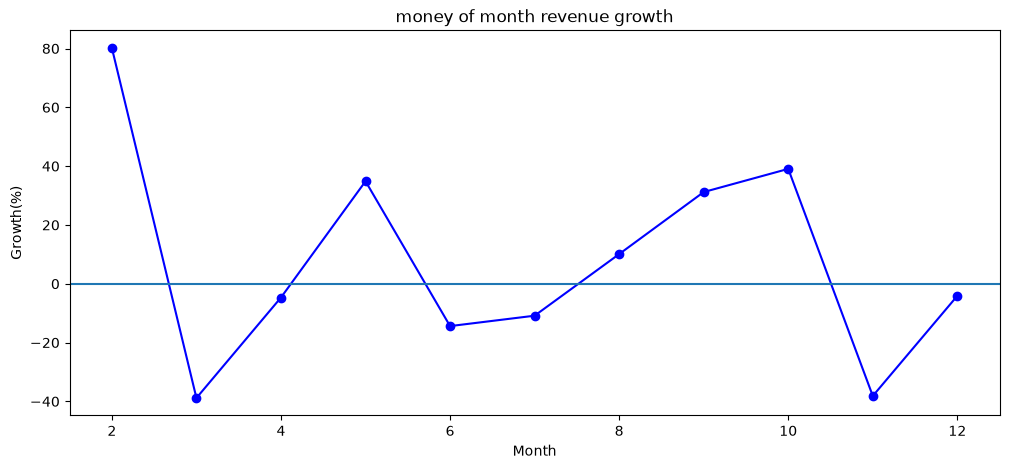

In [30]:
# chart: money of month growth
plt.figure(figsize=(12,5))
plt.plot(
    sales_monthly['month'],
    sales_monthly['MOM_Growth'],
    marker='o', color='b'
)

plt.axhline(0)
plt.title('money of month revenue growth')
plt.xlabel('Month')
plt.ylabel('Growth(%)');

In [31]:
# Classify transactions into morning or evening
df['am or pm']=df['hour'].apply(lambda x: 'pm' if x>=12 else 'am')
# Sales account for each period
df.groupby('am or pm')['money'].sum()

am or pm
am    33154.36
pm    70604.74
Name: money, dtype: float64

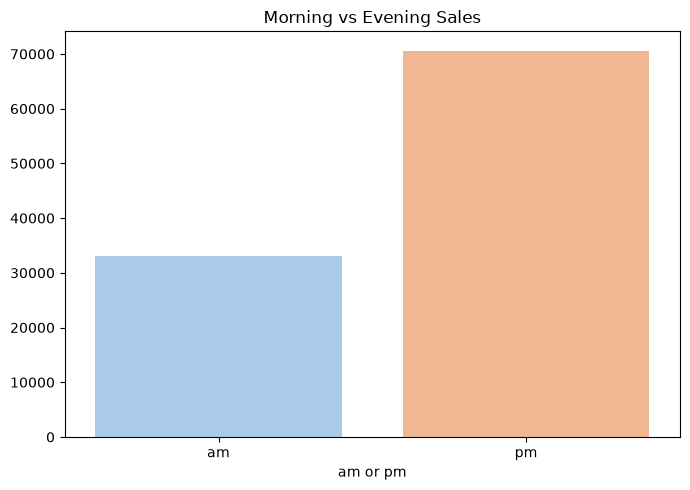

In [32]:
# Sales chart for morning and evening
period= df.groupby('am or pm')['money'].sum()
plt.figure(figsize=(7,5))
sns.barplot(x=period.index, y=period.values, hue=period.index,  palette='pastel')
plt.title('Morning vs Evening Sales')
plt.tight_layout()
